[INFO] Raw neural shape: (39209, 118)
[INFO] Interpreting raw neural matrix as neurons x presentations.
[INFO] Presentation-level neural shape: (118, 39209)
[WARN] No explicit stimulus_ids.npy found. Assuming PRESENTATION_ORDER='block'. Repeats per stimulus=1.
[INFO] Averaged neural responses by stimulus.
[INFO] Stimulus-averaged neural shape: (118, 39209)
[INFO] Presentations per stimulus: min=1, max=1


(array([1.098585e+06, 0.000000e+00, 1.218797e+06, 0.000000e+00,
        8.573570e+05, 0.000000e+00, 5.153760e+05, 0.000000e+00,
        3.006460e+05, 0.000000e+00, 1.836520e+05, 0.000000e+00,
        1.184230e+05, 0.000000e+00, 8.032900e+04, 0.000000e+00,
        5.697000e+04, 0.000000e+00, 4.186300e+04, 0.000000e+00,
        3.151900e+04, 0.000000e+00, 2.377600e+04, 0.000000e+00,
        1.848900e+04, 0.000000e+00, 1.469600e+04, 0.000000e+00,
        1.154200e+04, 0.000000e+00, 9.205000e+03, 0.000000e+00,
        7.303000e+03, 0.000000e+00, 6.075000e+03, 0.000000e+00,
        4.752000e+03, 0.000000e+00, 3.877000e+03, 0.000000e+00,
        3.177000e+03, 0.000000e+00, 2.590000e+03, 0.000000e+00,
        2.220000e+03, 0.000000e+00, 1.956000e+03, 0.000000e+00,
        1.515000e+03, 0.000000e+00, 1.356000e+03, 0.000000e+00,
        1.157000e+03, 0.000000e+00, 1.052000e+03, 0.000000e+00,
        9.490000e+02, 0.000000e+00, 7.730000e+02, 0.000000e+00,
        7.490000e+02, 0.000000e+00, 6.35

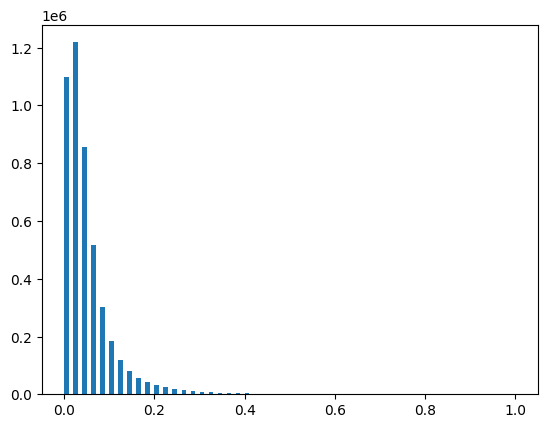

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("/home/maria/Science/thesis/experiments/007--PoorMansClassifier")
DATA_DIR = Path("/home/maria/Science/data")

OUT_DIR = BASE_DIR / "logistic_fisher_diagnostics"
OUT_DIR.mkdir(exist_ok=True, parents=True)

NEURAL_FILE = DATA_DIR / "hybrid_neural_responses_reduced.npy"

PRESENTATION_ORDER = "block"
STIMULUS_IDS_FILE = DATA_DIR / "stimulus_ids.npy"

N_STIMULI = 118


def load_neural_presentations() -> np.ndarray:
    if not NEURAL_FILE.exists():
        raise FileNotFoundError(f"Missing neural file: {NEURAL_FILE}")

    X_raw = np.asarray(np.load(NEURAL_FILE, allow_pickle=True))
    print(f"[INFO] Raw neural shape: {X_raw.shape}")

    if X_raw.ndim != 2:
        raise ValueError(f"Expected 2D neural matrix, got {X_raw.shape}")

    n0, n1 = X_raw.shape

    if n0 > n1 and n1 % N_STIMULI == 0:
        print("[INFO] Interpreting raw neural matrix as neurons x presentations.")
        X_pres = X_raw.T
    elif n1 > n0 and n0 % N_STIMULI == 0:
        print("[INFO] Interpreting raw neural matrix as presentations x neurons.")
        X_pres = X_raw
    else:
        raise ValueError(
            f"Could not infer orientation from neural shape {X_raw.shape}. "
            "Expected something like (39209, 118) or (118, 39209)."
        )

    X_pres = X_pres.astype(np.float32, copy=False)
    print(f"[INFO] Presentation-level neural shape: {X_pres.shape}")
    return X_pres

def make_presentation_stimulus_ids(n_presentations: int) -> np.ndarray:
    if STIMULUS_IDS_FILE.exists():
        stim_ids = np.load(STIMULUS_IDS_FILE, allow_pickle=True).astype(int).ravel()

        if len(stim_ids) != n_presentations:
            raise ValueError(
                f"{STIMULUS_IDS_FILE} has length {len(stim_ids)}, "
                f"but neural data has {n_presentations} presentations."
            )

        if stim_ids.min() < 0 or stim_ids.max() >= N_STIMULI:
            raise ValueError(
                f"Stimulus IDs must be in [0, {N_STIMULI - 1}], "
                f"got min={stim_ids.min()}, max={stim_ids.max()}."
            )

        print(f"[INFO] Loaded explicit stimulus IDs from {STIMULUS_IDS_FILE}")
        return stim_ids

    if n_presentations % N_STIMULI != 0:
        raise ValueError(
            f"n_presentations={n_presentations} is not divisible by {N_STIMULI}."
        )

    repeats = n_presentations // N_STIMULI

    if PRESENTATION_ORDER == "block":
        stim_ids = np.repeat(np.arange(N_STIMULI), repeats)
    elif PRESENTATION_ORDER == "cycle":
        stim_ids = np.tile(np.arange(N_STIMULI), repeats)
    else:
        raise ValueError("PRESENTATION_ORDER must be either 'block' or 'cycle'.")

    print(
        f"[WARN] No explicit {STIMULUS_IDS_FILE.name} found. "
        f"Assuming PRESENTATION_ORDER={PRESENTATION_ORDER!r}. "
        f"Repeats per stimulus={repeats}."
    )

    return stim_ids.astype(int)

def average_presentations_by_stimulus(X_pres: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n_presentations, n_neurons = X_pres.shape
    stim_ids = make_presentation_stimulus_ids(n_presentations)

    X_avg = np.zeros((N_STIMULI, n_neurons), dtype=np.float32)
    counts = np.zeros(N_STIMULI, dtype=int)

    for stim_id in range(N_STIMULI):
        mask = stim_ids == stim_id
        counts[stim_id] = int(mask.sum())

        if counts[stim_id] == 0:
            raise ValueError(f"Stimulus {stim_id} has zero presentations.")

        X_avg[stim_id] = X_pres[mask].mean(axis=0)

    print("[INFO] Averaged neural responses by stimulus.")
    print(f"[INFO] Stimulus-averaged neural shape: {X_avg.shape}")
    print(f"[INFO] Presentations per stimulus: min={counts.min()}, max={counts.max()}")

    return X_avg, counts

X_pres=load_neural_presentations()
X_avg, counts = average_presentations_by_stimulus(X_pres)

X_avg

plt.hist(X_avg.flatten(), bins=100)

Gamma shape: 1.6740880736745025
Gamma scale: 0.037280507
Zero fraction: 0.23744656514783227


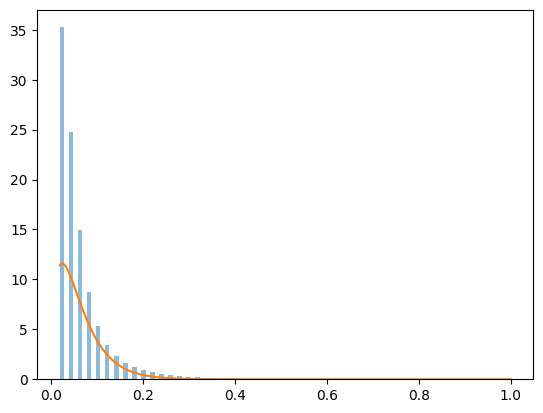

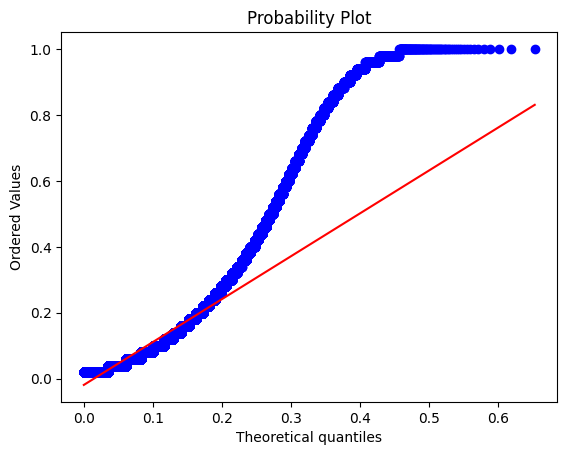

In [4]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

x = X_avg.flatten()
x = x[np.isfinite(x)]
x_pos = x[x > 0]

# Fit gamma to positive values only
shape, loc, scale = stats.gamma.fit(x_pos, floc=0)

print("Gamma shape:", shape)
print("Gamma scale:", scale)
print("Zero fraction:", np.mean(x == 0))

# Plot empirical histogram + fitted gamma density
plt.hist(x_pos, bins=100, density=True, alpha=0.5)

grid = np.linspace(x_pos.min(), x_pos.max(), 500)
plt.plot(grid, stats.gamma.pdf(grid, shape, loc=0, scale=scale))
plt.show()

# QQ plot
stats.probplot(x_pos, dist=stats.gamma, sparams=(shape, 0, scale), plot=plt)
plt.show()

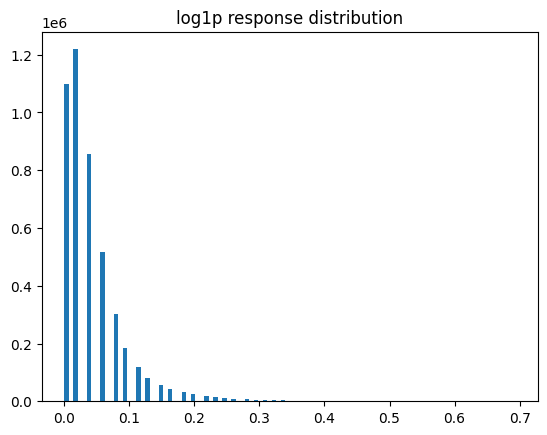

In [5]:
plt.hist(np.log1p(X_avg.flatten()), bins=100)
plt.title("log1p response distribution")
plt.show()

In [6]:
X_pres.flatten().mean()

np.float32(0.04759161)